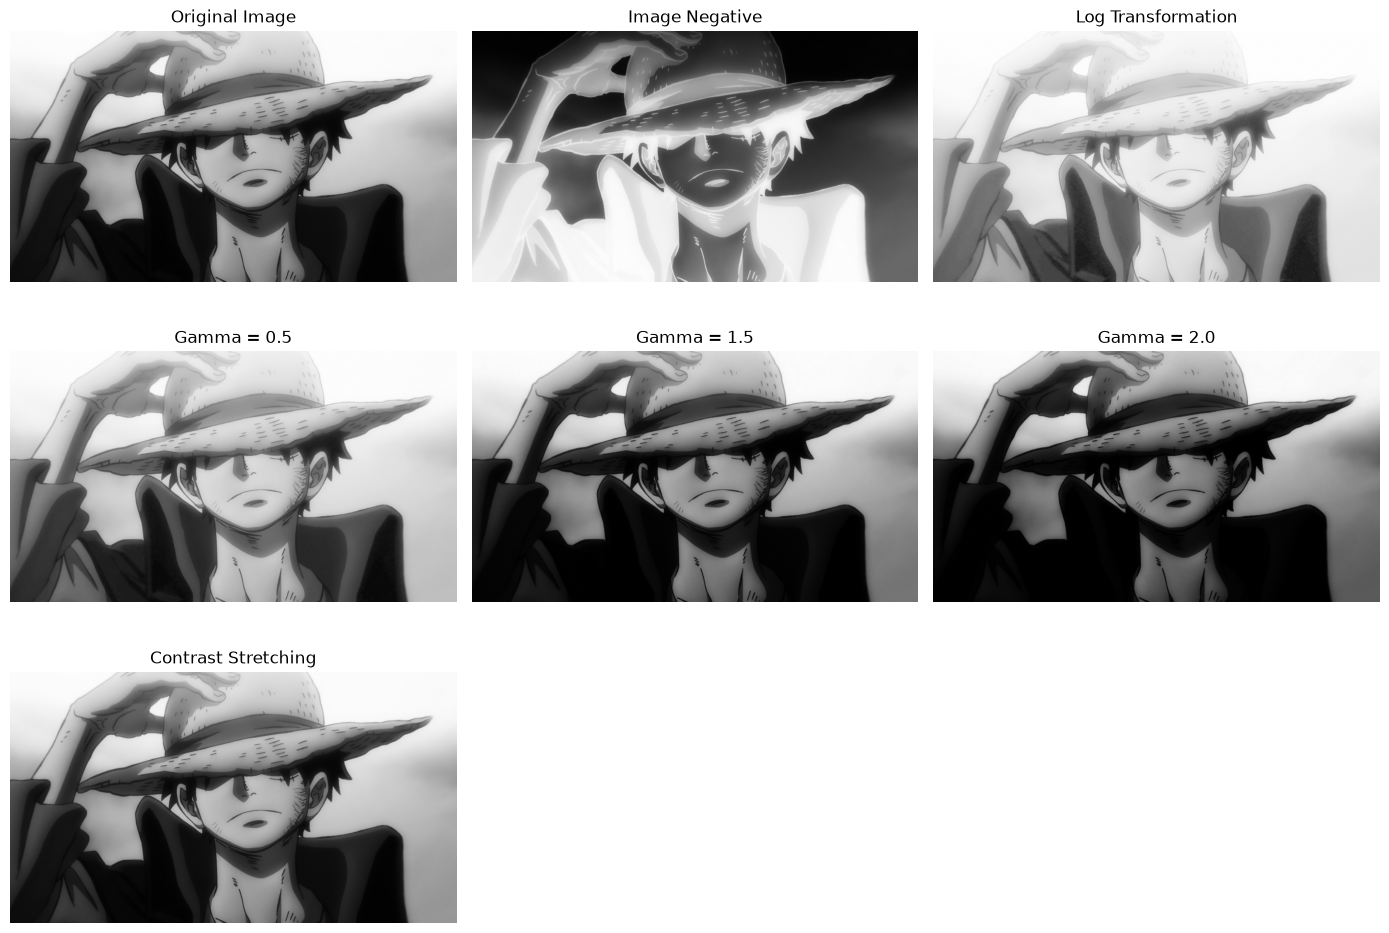

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------------
# Step 1: Read the input image
# -----------------------------------------

image = cv2.imread("luffy.jpg")

# Check whether image is loaded
if image is None:
    print("Error: Image not found.")
    exit()

# Convert BGR image to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)


# -----------------------------------------
# Step 2: Image Negative
# -----------------------------------------

negative = 255 - gray


# -----------------------------------------
# Step 3: Logarithmic Transformation
# -----------------------------------------

# Convert image to float
gray_float = gray.astype(np.float32)

# Calculate scaling constant
c = 255 / np.log(1 + np.max(gray_float))

# Apply log transformation
log_transform = c * np.log(1 + gray_float)

# Convert to uint8
log_transform = np.uint8(log_transform)


# -----------------------------------------
# Step 4: Power-Law / Gamma Transformation
# -----------------------------------------

# Normalize pixel values between 0 and 1
normalized = gray / 255.0

# Gamma values
gamma1 = 0.5
gamma2 = 1.5
gamma3 = 2.0

# Apply gamma transformations
gamma_05 = np.uint8(255 * (normalized ** gamma1))
gamma_15 = np.uint8(255 * (normalized ** gamma2))
gamma_20 = np.uint8(255 * (normalized ** gamma3))


# -----------------------------------------
# Step 5: Contrast Stretching
# -----------------------------------------

r_min = np.min(gray)
r_max = np.max(gray)

contrast_stretched = ((gray - r_min) /
                      (r_max - r_min) * 255)

contrast_stretched = np.uint8(contrast_stretched)


# -----------------------------------------
# Step 6: Display Results
# -----------------------------------------

plt.figure(figsize=(14, 10))

plt.subplot(3, 3, 1)
plt.imshow(gray, cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(3, 3, 2)
plt.imshow(negative, cmap='gray')
plt.title("Image Negative")
plt.axis("off")

plt.subplot(3, 3, 3)
plt.imshow(log_transform, cmap='gray')
plt.title("Log Transformation")
plt.axis("off")

plt.subplot(3, 3, 4)
plt.imshow(gamma_05, cmap='gray')
plt.title("Gamma = 0.5")
plt.axis("off")

plt.subplot(3, 3, 5)
plt.imshow(gamma_15, cmap='gray')
plt.title("Gamma = 1.5")
plt.axis("off")

plt.subplot(3, 3, 6)
plt.imshow(gamma_20, cmap='gray')
plt.title("Gamma = 2.0")
plt.axis("off")

plt.subplot(3, 3, 7)
plt.imshow(contrast_stretched, cmap='gray')
plt.title("Contrast Stretching")
plt.axis("off")

plt.tight_layout()
plt.show()
